# Customer Churn Analysis & Insights Dashboard
**Data Science Project**  
**Dataset:** Telco Customer Churn (IBM Sample Dataset)

---

## Objective
The goal of this project is to explore customer churn patterns in a telecom company. Instead of just predicting who will leave, we focus on *understanding why* they leave — which segments are at risk, what behaviors signal churn, and what business actions can reduce it.


## Step 1: Importing Libraries

Before doing anything with data, we need to load the tools we'll use:

- **pandas** — for manipulating data
- **numpy** — for numerical operations
- **matplotlib** — the core plotting library in Python. `pyplot` is the part of matplotlib we use most — it gives us functions like `plt.plot()`, `plt.bar()`, etc.
- **seaborn** — makes more statistical charts with less code

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# setting a clean visual style for all our charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

## Step 2: Loading the Dataset

We're using the **Telco Customer Churn** datasetfrom Kaggle:  
site -  https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Place the CSV file in the same folder as this notebook and run the cell below.

The dataset contains ~7,000 customers with information like:
- How long they've been with the company (`tenure`)
- What services they use (internet, phone, streaming)
- Their monthly and total charges
- Whether they churned (`Churn` column — Yes/No)

In [40]:
#readingg csv file
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

#name of the colummns, you can skip this if no. of columns in your data set is more
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: 7043 rows, 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [41]:
# head() - gives the first five rows, an function of pandas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Data Cleaning

We need to clean the data by:
1. Checking for missing values
2. Fixing data types (e.g., `TotalCharges` comes in as text, not a number)
3. Convert the `Churn` column from Yes/No to 1/0 so we can do arithmetic operations on it

In [42]:
# Check data types and nulls
print(df.dtypes)
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values per column:
Series([], dtype: int64)


In [43]:
# fixing spaces of TotalCharges and checking whether there can be errors generated or not while data conversion, ex : string to int conversion 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# fillin with 0 and modifying the original data by using inplace = TRUE
df['TotalCharges'].fillna(0, inplace=True)

# Convert Churn to binary: 1 = churned, 0 = stayed
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert SeniorCitizen from 0/1 to readable labels
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({1: 'Senior', 0: 'Non-Senior'})

print("Cleaning done. Dataset is ready for analysis.")
print(f"Total customers: {len(df)}")
print(f"Churned: {df['Churn_Binary'].sum()} ({df['Churn_Binary'].mean()*100:.1f}%)")
print(f"Retained: {(df['Churn_Binary'] == 0).sum()} ({(1 - df['Churn_Binary'].mean())*100:.1f}%)")

Cleaning done. Dataset is ready for analysis.
Total customers: 7043
Churned: 1869 (26.5%)
Retained: 5174 (73.5%)


## Step 4: Exploratory Data Analysis (EDA)

In this integral part we use data analytics methods and plots several graphs according to the provided data and its trends.

---

### 4.1 — How many customers actually churned?

**Matplotlib core work here is :** `fig, ax = plt.subplots()` creates a blank canvas (`fig`) with one drawing area (`ax`). We then call `ax.bar()` to draw bars. Think of `fig` as the paper and `ax` as where you actually draw.

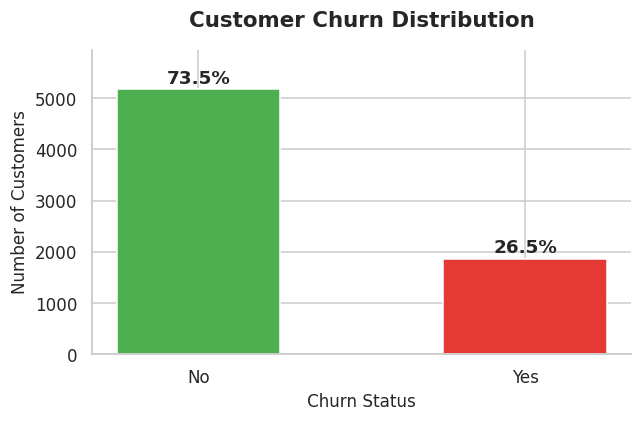


Insight: About 1 in 4 customers (26.5%) has churned. This is a significant loss and warrants investigation into the root causes.


In [44]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

#giving the colurs codes, green and red respectively.
colors = ['#4CAF50', '#E53935']
bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5, edgecolor='white')

# Add percentage labels on top of each bar
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, max(churn_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nInsight: About 1 in 4 customers (26.5%) has churned. This is a significant loss and warrants investigation into the root causes.")

### 4.2 — Tenure 

**Intuition:** Customers who just joined may leave quickly if they're unhappy. Long-term customers are likely more loyal.

**Chart type used:** Histogram — breaks the continuous `tenure` values into buckets and counts how many customers fall in each bucket, split by churn status.

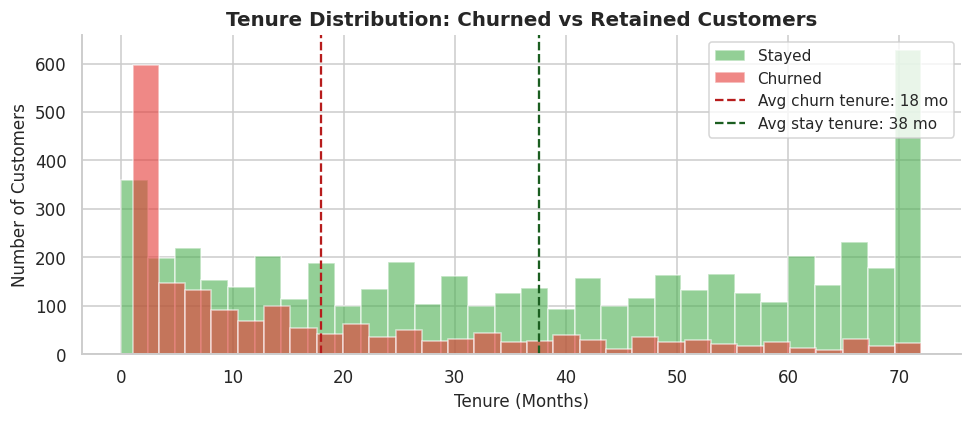

Average tenure of churned customers: 18.0 months
Average tenure of retained customers: 37.6 months

Insight: Churned customers have much shorter tenures on average. The highest churn happens in the first 1-5 months — this is the most critical retention window.


In [45]:
fig, ax = plt.subplots(figsize=(9, 4))

churned = df[df['Churn'] == 'Yes']['tenure']
stayed = df[df['Churn'] == 'No']['tenure']

ax.hist(stayed, bins=30, alpha=0.6, color='#4CAF50', label='Stayed', edgecolor='white')
ax.hist(churned, bins=30, alpha=0.6, color='#E53935', label='Churned', edgecolor='white')

ax.axvline(churned.mean(), color='#B71C1C', linestyle='--', linewidth=1.5, label=f'Avg churn tenure: {churned.mean():.0f} mo')
ax.axvline(stayed.mean(), color='#1B5E20', linestyle='--', linewidth=1.5, label=f'Avg stay tenure: {stayed.mean():.0f} mo')

ax.set_title('Tenure Distribution: Churned vs Retained Customers', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Average tenure of churned customers: {churned.mean():.1f} months")
print(f"Average tenure of retained customers: {stayed.mean():.1f} months")
print(f"\nInsight: Churned customers have much shorter tenures on average. The highest churn happens in the first 1-5 months — this is the most critical retention window.")

### 4.3 — Do higher monthly charges push customers to leave?

**Chart type used:** Box plot — shows the spread of values. The box represents the middle 50% of data, the line inside is the median, and the dots are outliers.

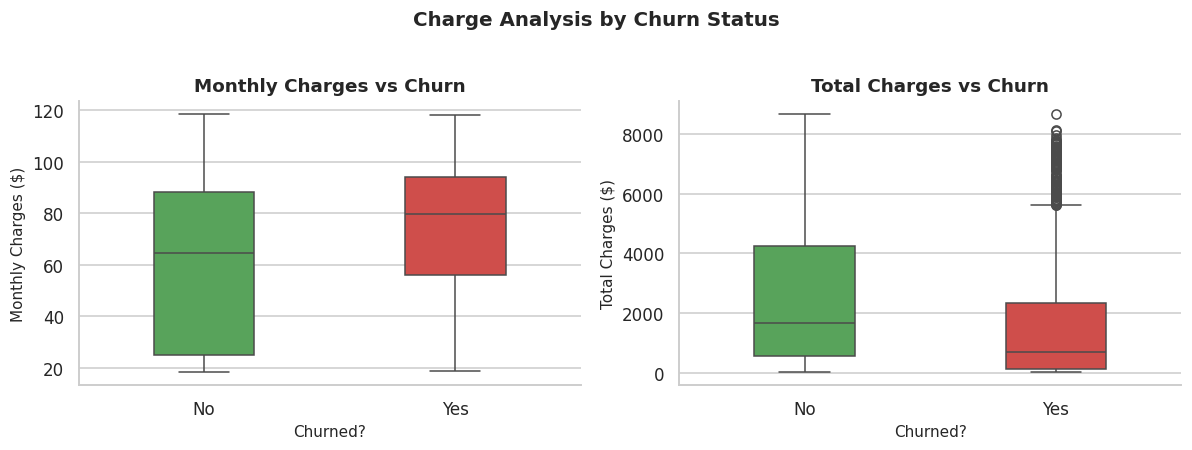

Avg monthly charge — Churned: $74.44 | Stayed: $61.27

Insight: Churned customers pay significantly higher monthly charges. This suggests pricing sensitivity — customers feel they're not getting enough value for what they pay.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Monthly Charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#4CAF50', 'Yes': '#E53935'},
            ax=axes[0], width=0.4)
axes[0].set_title('Monthly Charges vs Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churned?', fontsize=10)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=10)

# Total Charges
sns.boxplot(data=df, x='Churn', y='TotalCharges',
            palette={'No': '#4CAF50', 'Yes': '#E53935'},
            ax=axes[1], width=0.4)
axes[1].set_title('Total Charges vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churned?', fontsize=10)
axes[1].set_ylabel('Total Charges ($)', fontsize=10)

sns.despine()
plt.suptitle('Charge Analysis by Churn Status', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Avg monthly charge — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f} | Stayed: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"\nInsight: Churned customers pay significantly higher monthly charges. This suggests pricing sensitivity — customers feel they're not getting enough value for what they pay.")

### 4.4 — Contract

**Intuition:** A customer on a month-to-month plan can leave anytime. A specific year contract locks them. To find the trends in the data related to contract type we use : 

 Grouped bar chart — compares churn rate across different categories.

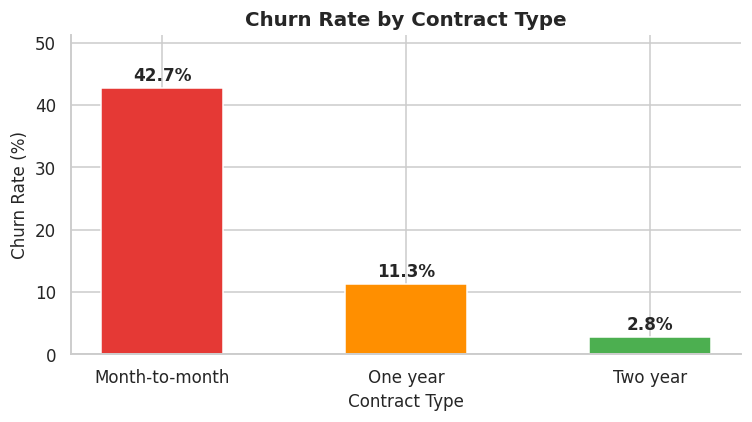

Insight: Month-to-month customers churn at an alarmingly high rate compared to customers on annual or bi-annual contracts. Encouraging customers to upgrade to longer plans could be a powerful retention lever.


In [47]:
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']
contract_churn['Churn Rate'] *= 100
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))

bar_colors = ['#E53935', '#FF8F00', '#4CAF50']
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate'],
              color=bar_colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, contract_churn['Churn Rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, max(contract_churn['Churn Rate']) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

print("Insight: Month-to-month customers churn at an alarmingly high rate compared to customers on annual or bi-annual contracts. Encouraging customers to upgrade to longer plans could be a powerful retention lever.")

### 4.5 — Internet service type

This is important because different service types have very different pricing and quality. Fiber optic is faster but also more expensive, which may drive churn


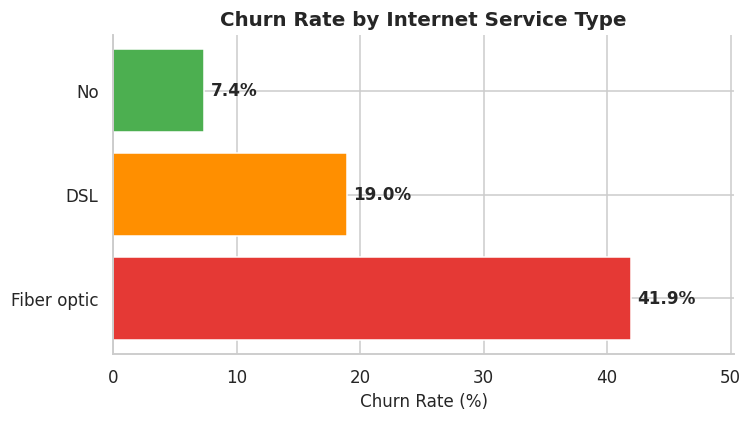

Insight: Fiber optic users churn the most. Despite the faster speeds, they likely experience higher charges without a proportional sense of value — or face quality/support issues.


In [48]:
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().reset_index()
internet_churn.columns = ['Internet Service', 'Churn Rate']
internet_churn['Churn Rate'] *= 100
internet_churn = internet_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))

palette = ['#E53935', '#FF8F00', '#4CAF50']
bars = ax.barh(internet_churn['Internet Service'], internet_churn['Churn Rate'],
               color=palette, edgecolor='white')

for bar, val in zip(bars, internet_churn['Churn Rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_xlim(0, max(internet_churn['Churn Rate']) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

print("Insight: Fiber optic users churn the most. Despite the faster speeds, they likely experience higher charges without a proportional sense of value — or face quality/support issues.")

### 4.6 — Churn by Senior Citizen Status and Gender

Let's check if demographic factors play a role in churn behavior.

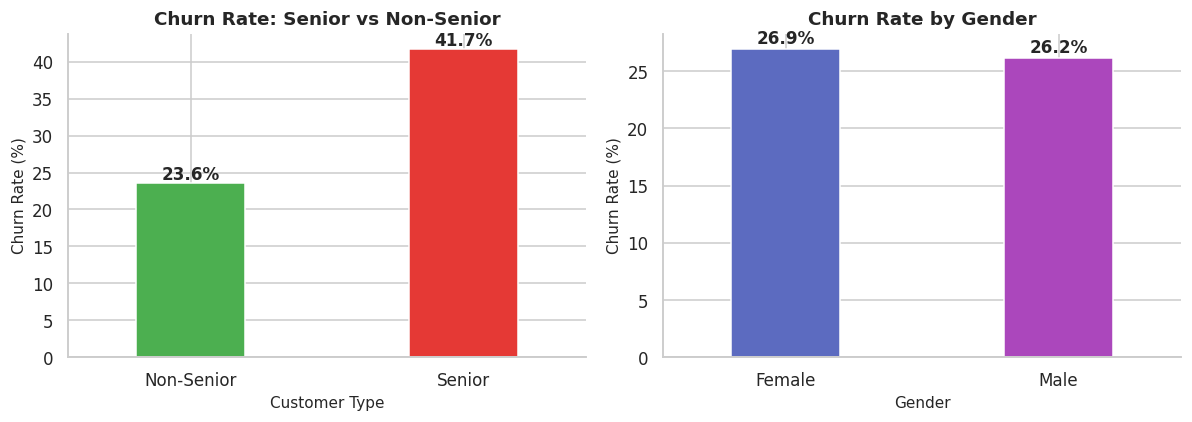

Insight: Senior citizens churn at almost double the rate of non-seniors — they may need more support or simpler plan options. Gender, on the other hand, shows almost no difference in churn rate.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Senior Citizen
senior_churn = df.groupby('SeniorCitizen_Label')['Churn_Binary'].mean() * 100
senior_churn.plot(kind='bar', ax=axes[0],
                  color=['#4CAF50', '#E53935'], edgecolor='white', width=0.4)
axes[0].set_title('Churn Rate: Senior vs Non-Senior', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Type', fontsize=10)
axes[0].set_ylabel('Churn Rate (%)', fontsize=10)
axes[0].set_xticklabels(['Non-Senior', 'Senior'], rotation=0)
for i, v in enumerate(senior_churn):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Gender
gender_churn = df.groupby('gender')['Churn_Binary'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1],
                  color=['#5C6BC0', '#AB47BC'], edgecolor='white', width=0.4)
axes[1].set_title('Churn Rate by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=10)
axes[1].set_ylabel('Churn Rate (%)', fontsize=10)
axes[1].set_xticklabels(gender_churn.index, rotation=0)
for i, v in enumerate(gender_churn):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print("Insight: Senior citizens churn at almost double the rate of non-seniors — they may need more support or simpler plan options. Gender, on the other hand, shows almost no difference in churn rate.")

## Step 5: Summary of Key Findings

In this, we'll take insights from the findings that we got from analysing this particular data across various major factors.

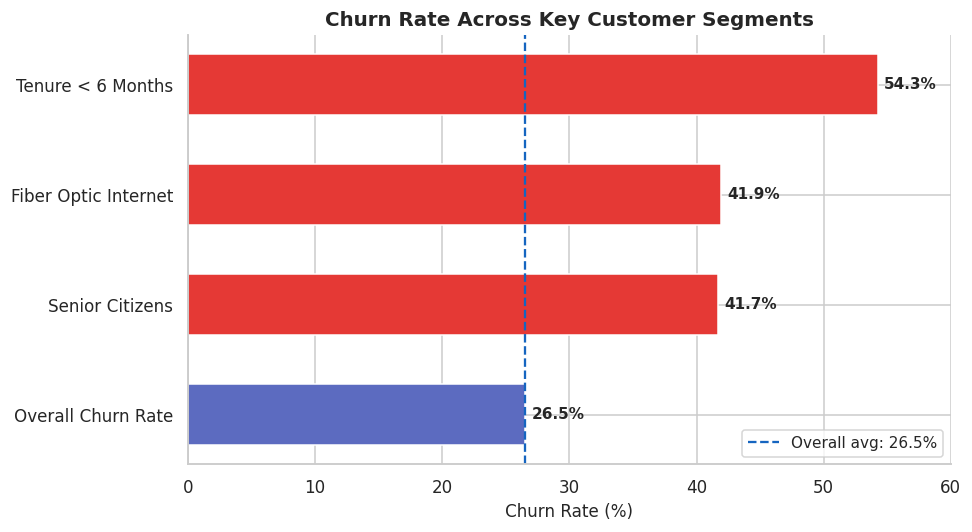

In [50]:
#summary of churn rates across key segments
summary = {
    'Fiber Optic Internet': df[df['InternetService'] == 'Fiber optic']['Churn_Binary'].mean() * 100,
    'Senior Citizens': df[df['SeniorCitizen'] == 1]['Churn_Binary'].mean() * 100,
    'Tenure < 6 Months': df[df['tenure'] < 6]['Churn_Binary'].mean() * 100,
    'Overall Churn Rate': df['Churn_Binary'].mean() * 100,
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Segment', 'Churn Rate (%)'])
summary_df = summary_df.sort_values('Churn Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E53935' if s != 'Overall Churn Rate' else '#5C6BC0' for s in summary_df['Segment']]
bars = ax.barh(summary_df['Segment'], summary_df['Churn Rate (%)'],
               color=colors, edgecolor='white', height=0.55)

for bar, val in zip(bars, summary_df['Churn Rate (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(df['Churn_Binary'].mean() * 100, color='#1565C0', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {df["Churn_Binary"].mean()*100:.1f}%')

ax.set_title('Churn Rate Across Key Customer Segments', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_xlim(0, 60)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## Step 6: Business Recommendations

Based on our analysis, here are actionable insights that the business can act on:

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Month-to-month customers churn the most** | Offer discounts or perks to nudge customers toward annual/2-year contracts |
| 2 | **New customers (< 6 months) are highest risk** | Implement an onboarding program with check-ins in months 1–3 |
| 3 | **High monthly charges correlate with churn** | Introduce mid-tier plans or loyalty discounts for high-paying customers |
| 4 | **Fiber optic users churn at 42%** | Investigate service quality and customer support satisfaction in this segment |
| 5 | **Senior citizens churn at 2x rate** | Create dedicated support lines or simplified plan offerings for senior users |

---

## Conclusion

This analysis reveals that customer churn is not random — it is strongly driven by **contract flexibility, pricing, service type, and customer tenure**. The first 6 months and month-to-month contract holders represent the most critical intervention points. By targeting these high-risk segments with focused retention strategies, the business can meaningfully reduce churn and improve long-term revenue stability.